In [ ]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [ ]:
dataset = pd.read_csv("NPHA-doctor-visits.csv")
dataset.head()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2


In [ ]:
vals = dataset["Race"].unique()
vals

array([1, 4, 2, 5, 3])

In [ ]:
# сохраняем только числовые столбцы. Целевую переменную убираем
cols_for_clusters = ['Number of Doctors Visited','Age','Phyiscal Health','Mental Health', 'Dental Health', 'Employment',
                     'Stress Keeps Patient from Sleeping', 'Medication Keeps Patient from Sleeping', 'Pain Keeps Patient from Sleeping',
                     'Bathroom Needs Keeps Patient from Sleeping', 'Uknown Keeps Patient from Sleeping', 'Trouble Sleeping', 'Prescription Sleep Medication',
                     'Gender']

df= dataset[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [ ]:
df.head()

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,2


In [ ]:
X = df
y = dataset["Race"].replace(vals, [1, 2, 3, 4, 5])
yvals = dataset["Race"]

пробуем разные алгоритмы

In [ ]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

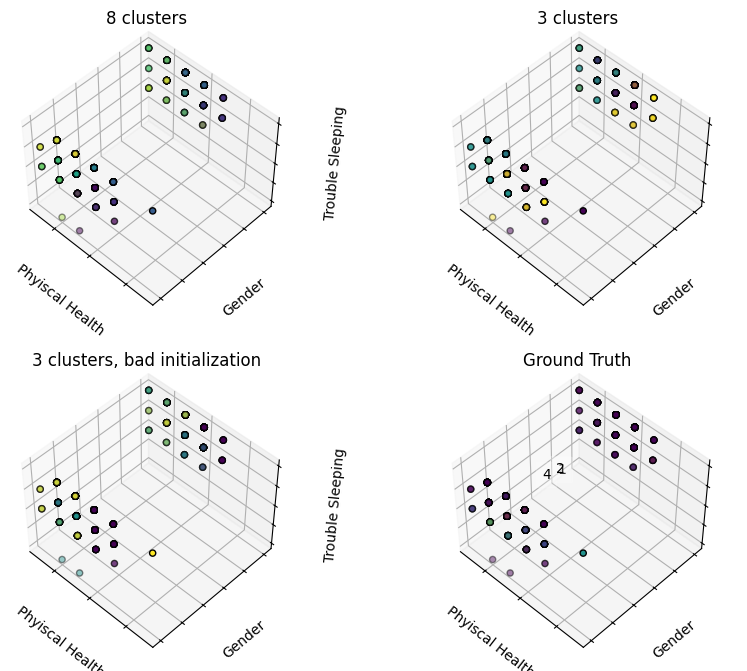

In [23]:
estimators = [
    ("k_means_8", KMeans(n_clusters=8)),
    ("k_means_3", KMeans(n_clusters=3)),
    ("k_means_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X["Phyiscal Health"], X["Gender"], X["Trouble Sleeping"], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Phyiscal Health")
    ax.set_ylabel("Gender")
    ax.set_zlabel("Trouble Sleeping")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [(vals[0], 0), (vals[1], 1), (vals[2], 2)]:
    ds = dataset[dataset["Race"]==name]
    ax.text3D(
        ds["Phyiscal Health"].mean(),
        ds["Gender"].mean(),
        ds["Trouble Sleeping"].mean(),
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X["Phyiscal Health"], X["Gender"], X["Trouble Sleeping"], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Phyiscal Health")
ax.set_ylabel("Gender")
ax.set_zlabel("Trouble Sleeping")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

метрики

In [ ]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [ ]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n

In [ ]:
best_metric

[np.int64(2),
 np.float64(0.21343390758270261),
 0.017835412949944767,
 array([[2.08064516, 2.        , 2.40092166, 1.63133641, 2.20046083,
         2.75576037, 0.23963134, 0.0437788 , 0.17511521, 0.49308756,
         0.42396313, 2.47004608, 2.86635945, 1.55760369],
        [2.16071429, 2.        , 3.40357143, 2.54285714, 4.26428571,
         2.88571429, 0.26071429, 0.075     , 0.28571429, 0.52142857,
         0.40714286, 2.31071429, 2.77142857, 1.53928571]])]

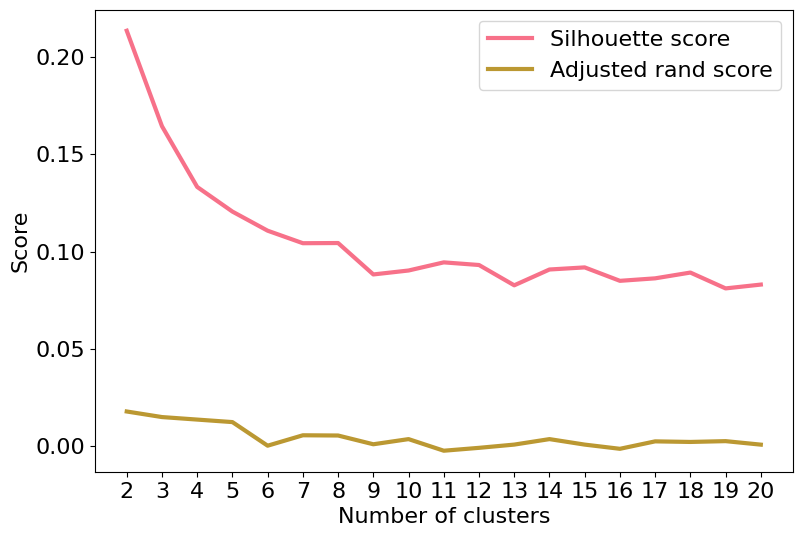

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()

Такое значение говорит о том, что объекты внутри кластеров почти такие же разные, как и объекты из разных кластеров. Границы между кластерами размыты, и выделенные группы нельзя назвать компактными и хорошо отделёнными.

иерархическая кластеризация

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

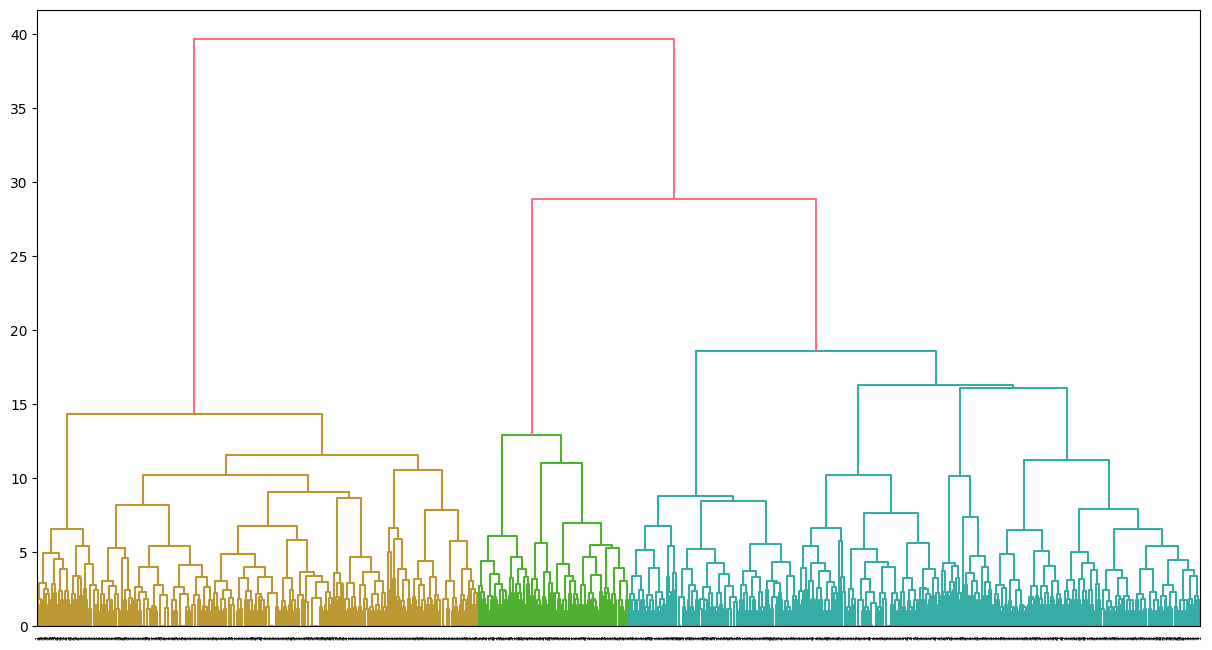

In [ ]:
samples = df.values

# Реализация иерархической кластеризации при помощи функции linkage
mergings = linkage(samples, method='ward')

plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

In [24]:
#реальные данные
samples_real = df.values
mergings_real = linkage(samples_real, method='ward')

#случайные данные того же размера
samples_random = np.random.randn(*samples_real.shape)
mergings_random = linkage(samples_random, method='ward')

#сравним расстояния слияния
print("Реальные данные - последние 5 расстояний:", mergings_real[-5:, 2])
print("Случайные данные - последние 5 расстояний:", mergings_random[-5:, 2])

Реальные данные - последние 5 расстояний: [16.09784177 16.26978008 18.56195831 28.86733656 39.67397347]
Случайные данные - последние 5 расстояний: [19.91442464 20.19669472 20.44743875 23.4871734  24.33046618]


из этого можно сделать вывод, что структура у данных плохо выражена, есть хоть какой-то намек на структуру в последних двух классах

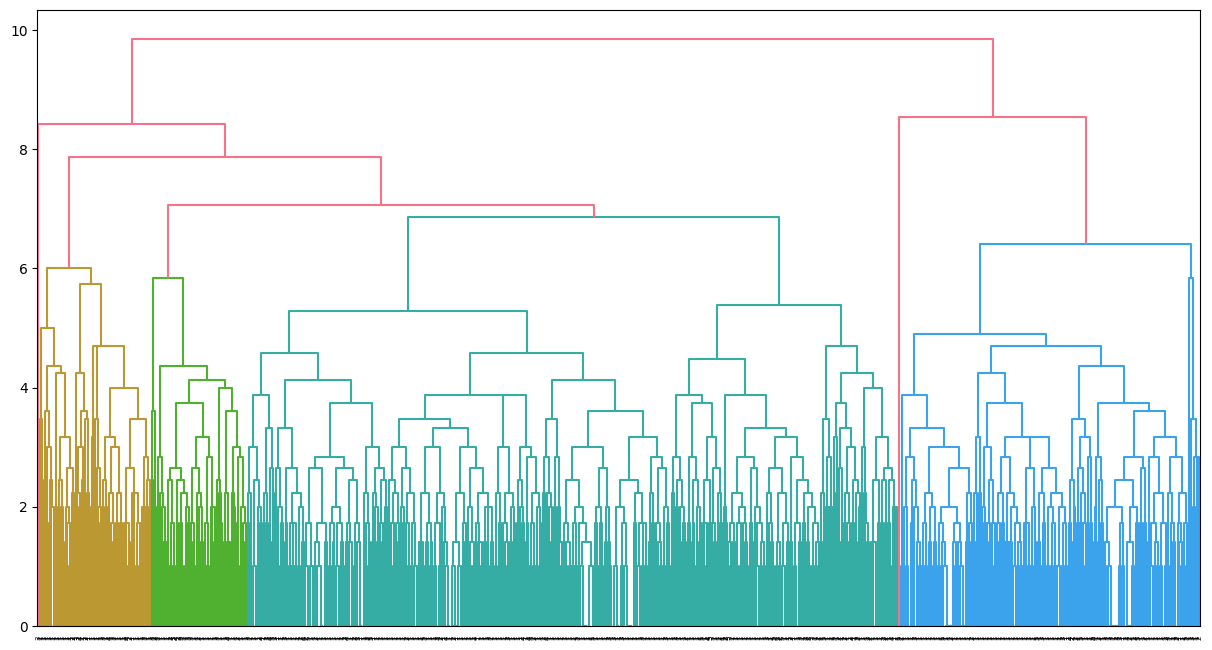

In [27]:
mergings = linkage(samples, method='complete')
plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

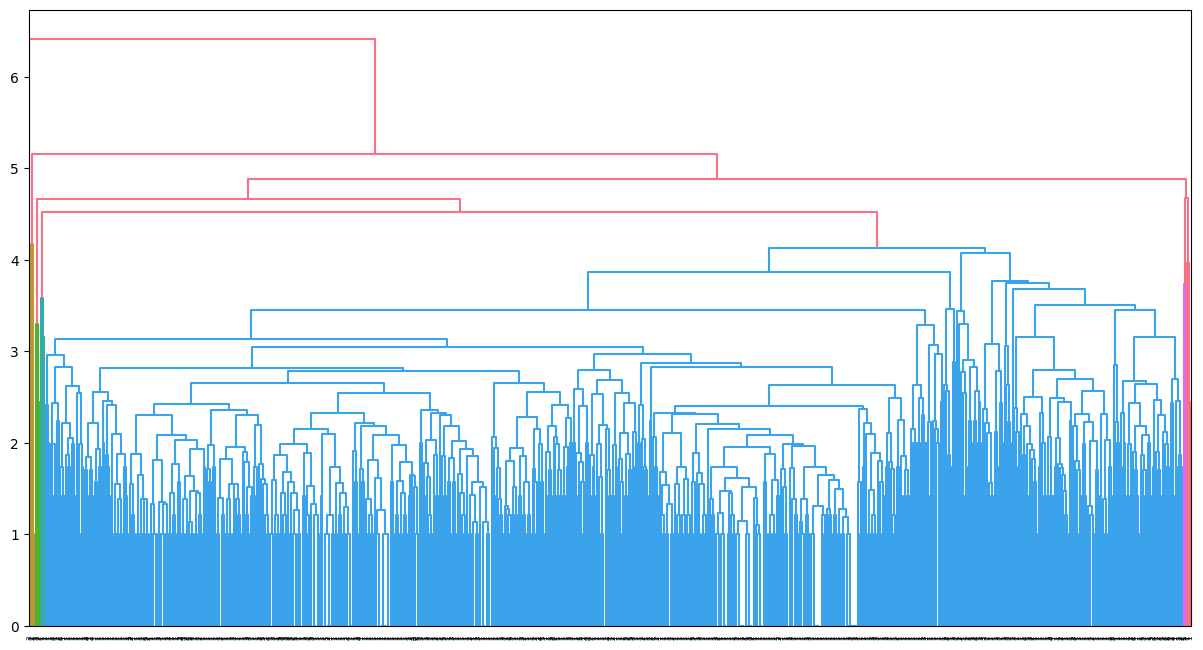

In [28]:
mergings = linkage(samples, method='average')
plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

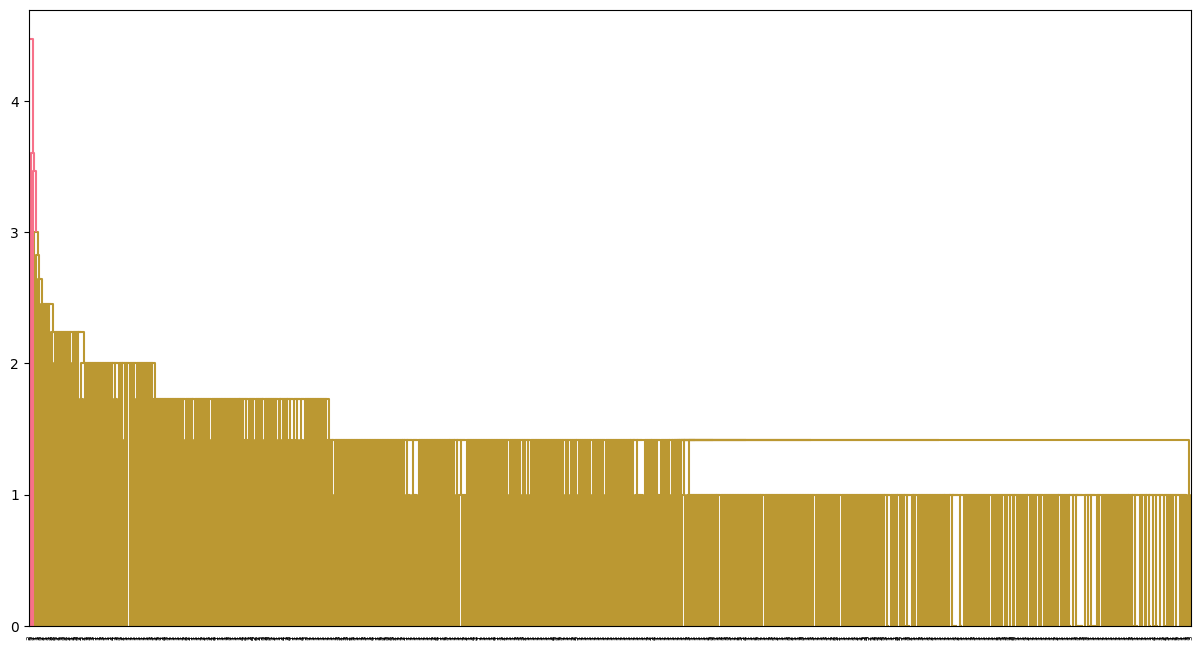

In [29]:
mergings = linkage(samples, method='single')
plt.figure(figsize=(15, 8))
# Строим дендрограмму, указав параметры удобные для отображения
dendrogram(mergings,
           labels=list(y),
           leaf_rotation=90,
           leaf_font_size=5,
           )

plt.show()

лучше всего выглядит метод complete

In [30]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

# Используем complete
mergings = linkage(samples, method='complete')

# Подбираем оптимальное количество кластеров
silhouette_scores = []
for k in range(2, 11):
    labels = fcluster(mergings, t=k, criterion='maxclust')
    if len(set(labels)) > 1:
        sil = silhouette_score(samples, labels)
        silhouette_scores.append(sil)
        print(f"k={k}: силуэт = {sil:.3f}")

best_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f"\nОптимальное число кластеров: {best_k}")

k=2: силуэт = 0.124
k=3: силуэт = 0.121
k=4: силуэт = 0.122
k=5: силуэт = 0.088
k=6: силуэт = 0.076
k=7: силуэт = 0.070
k=8: силуэт = 0.071
k=9: силуэт = 0.073
k=10: силуэт = 0.073

Оптимальное число кластеров: 2


In [31]:
best_labels = fcluster(mergings, t=2, criterion='maxclust')

from sklearn.metrics import adjusted_rand_score, confusion_matrix
import pandas as pd

ari = adjusted_rand_score(y, best_labels)
print(f"ARI = {ari:.3f}")

# Таблица соответствия кластеров и истинных классов
conf_matrix = pd.crosstab(y, best_labels, rownames=['Истинный класс'], colnames=['Кластер'])
print(conf_matrix)

ARI = -0.015
Кластер           1    2
Истинный класс          
1               425  153
2                33   11
3                40   12
4                18    2
5                13    7


Проведённый анализ иерархической кластеризации с использованием методов ward, complete, average и single показал, что убедительная кластерная структура в данных отсутствует. Значения силуэта не превышают 0.12, что свидетельствует о низкой компактности выделенных групп. Совпадение с истинными метками не лучше случайного. Таким образом, данные не разделяются на естественные кластеры

DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [36]:
# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Подбор параметров DBSCAN
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [5, 10, 12, 15]

best_silhouette = -1
best_params = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        # Количество кластеров (исключая шум)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Силуэт считаем только если есть хотя бы 2 кластера и не все объекты в шуме
        if n_clusters >= 2 and n_noise < len(X_scaled) - 1:
            sil = metrics.silhouette_score(X_scaled, labels)
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise}, силуэт={sil:.3f}")

            if sil > best_silhouette:
                best_silhouette = sil
                best_params = {'eps': eps, 'min_samples': min_samples}
        else:
            print(f"eps={eps}, min_samples={min_samples}: кластеров={n_clusters}, шума={n_noise} → силуэт не считается")

print(f"\nЛучшие параметры: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
print(f"Лучший силуэт: {best_silhouette:.3f}")

# Запускаем DBSCAN с лучшими параметрами
db_best = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
labels_best = db_best.fit_predict(X_scaled)

n_clusters = len(set(labels_best)) - (1 if -1 in labels_best else 0)
n_noise = list(labels_best).count(-1)

print(f"\nИтог: {n_clusters} кластеров, {n_noise} точек шума")

eps=0.3, min_samples=5: кластеров=3, шума=698, силуэт=-0.233
eps=0.3, min_samples=10: кластеров=0, шума=714 → силуэт не считается
eps=0.3, min_samples=12: кластеров=0, шума=714 → силуэт не считается
eps=0.3, min_samples=15: кластеров=0, шума=714 → силуэт не считается
eps=0.5, min_samples=5: кластеров=3, шума=698, силуэт=-0.233
eps=0.5, min_samples=10: кластеров=0, шума=714 → силуэт не считается
eps=0.5, min_samples=12: кластеров=0, шума=714 → силуэт не считается
eps=0.5, min_samples=15: кластеров=0, шума=714 → силуэт не считается
eps=0.7, min_samples=5: кластеров=3, шума=698, силуэт=-0.233
eps=0.7, min_samples=10: кластеров=0, шума=714 → силуэт не считается
eps=0.7, min_samples=12: кластеров=0, шума=714 → силуэт не считается
eps=0.7, min_samples=15: кластеров=0, шума=714 → силуэт не считается
eps=1.0, min_samples=5: кластеров=9, шума=663, силуэт=-0.260
eps=1.0, min_samples=10: кластеров=0, шума=714 → силуэт не считается
eps=1.0, min_samples=12: кластеров=0, шума=714 → силуэт не считает

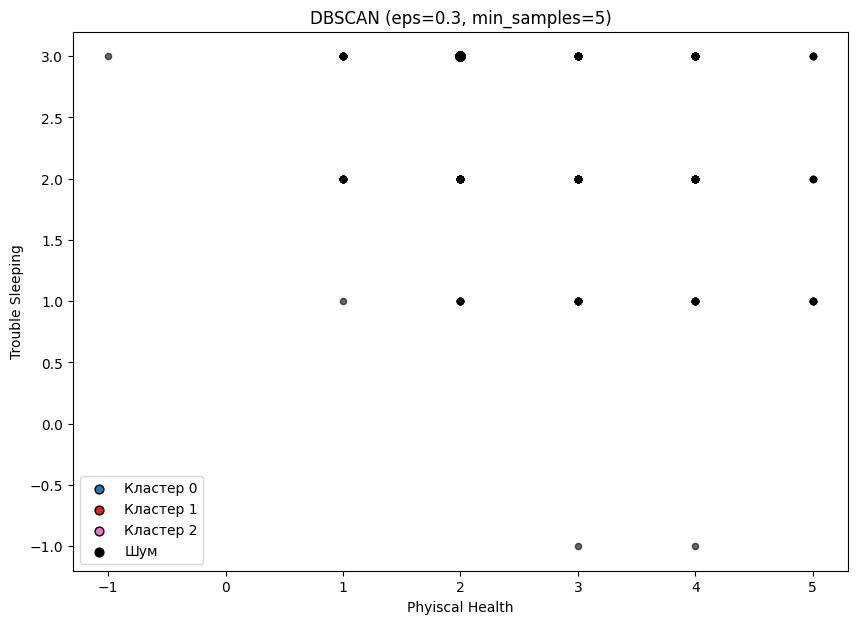

In [35]:
# Исправленный код визуализации для DBSCAN
core_samples_mask = np.zeros_like(labels_best, dtype=bool)
core_samples_mask[db_best.core_sample_indices_] = True

# Цвета для кластеров (включая шум)
unique_labels = set(labels_best)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(10, 7))

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Шум — чёрный
        col = 'k'
        label = 'Шум'
    else:
        label = f'Кластер {k}'

    class_member_mask = (labels_best == k)

    # Ядерные точки
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy["Phyiscal Health"], xy["Trouble Sleeping"],
                c=[col], marker='o', s=40, edgecolor='k', label=label)

    # Периферийные точки
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy["Phyiscal Health"], xy["Trouble Sleeping"],
                c=[col], marker='o', s=20, alpha=0.6)

plt.xlabel("Phyiscal Health")
plt.ylabel("Trouble Sleeping")
plt.title(f"DBSCAN (eps={best_params['eps']}, min_samples={best_params['min_samples']})")
plt.legend()
plt.show()

данных всего 714 строчек, он отнес 698 к шуму, все-таки в этих данных нет четкой структуры классов